<a href="https://colab.research.google.com/github/ap-ctrl/celebal_ankita/blob/main/week2_ankita_priyadarshini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





# STEP 1 — Import Libraries

In [1]:

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# STEP 2 — Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


# STEP 3 — Understanding the Dataset

In [3]:
df.head()
df.tail()
df.shape
df.columns
df.dtypes
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


# STEP 4 — Data Cleaning

In [4]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [5]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_535/3551297251.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [6]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_535/719105301.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

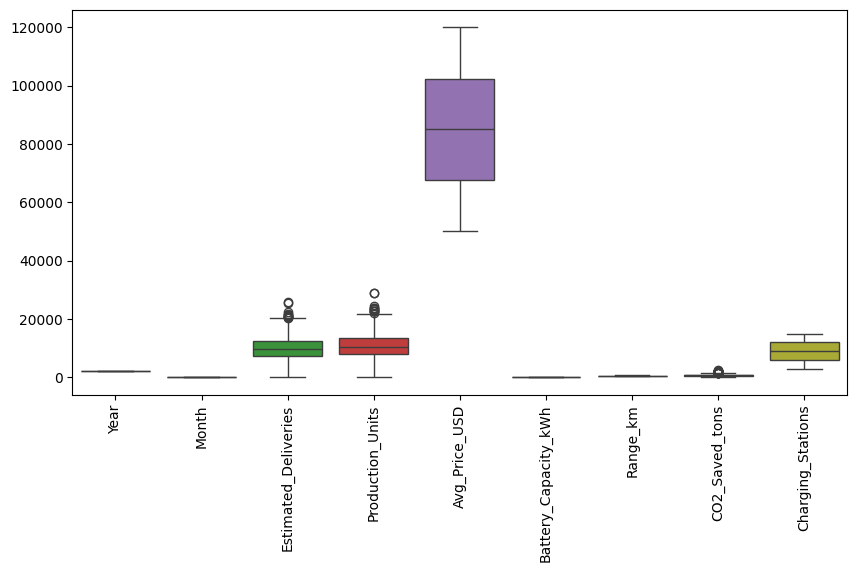

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()

# STEP 5 — Exploratory Data Analysis (EDA)

In [10]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


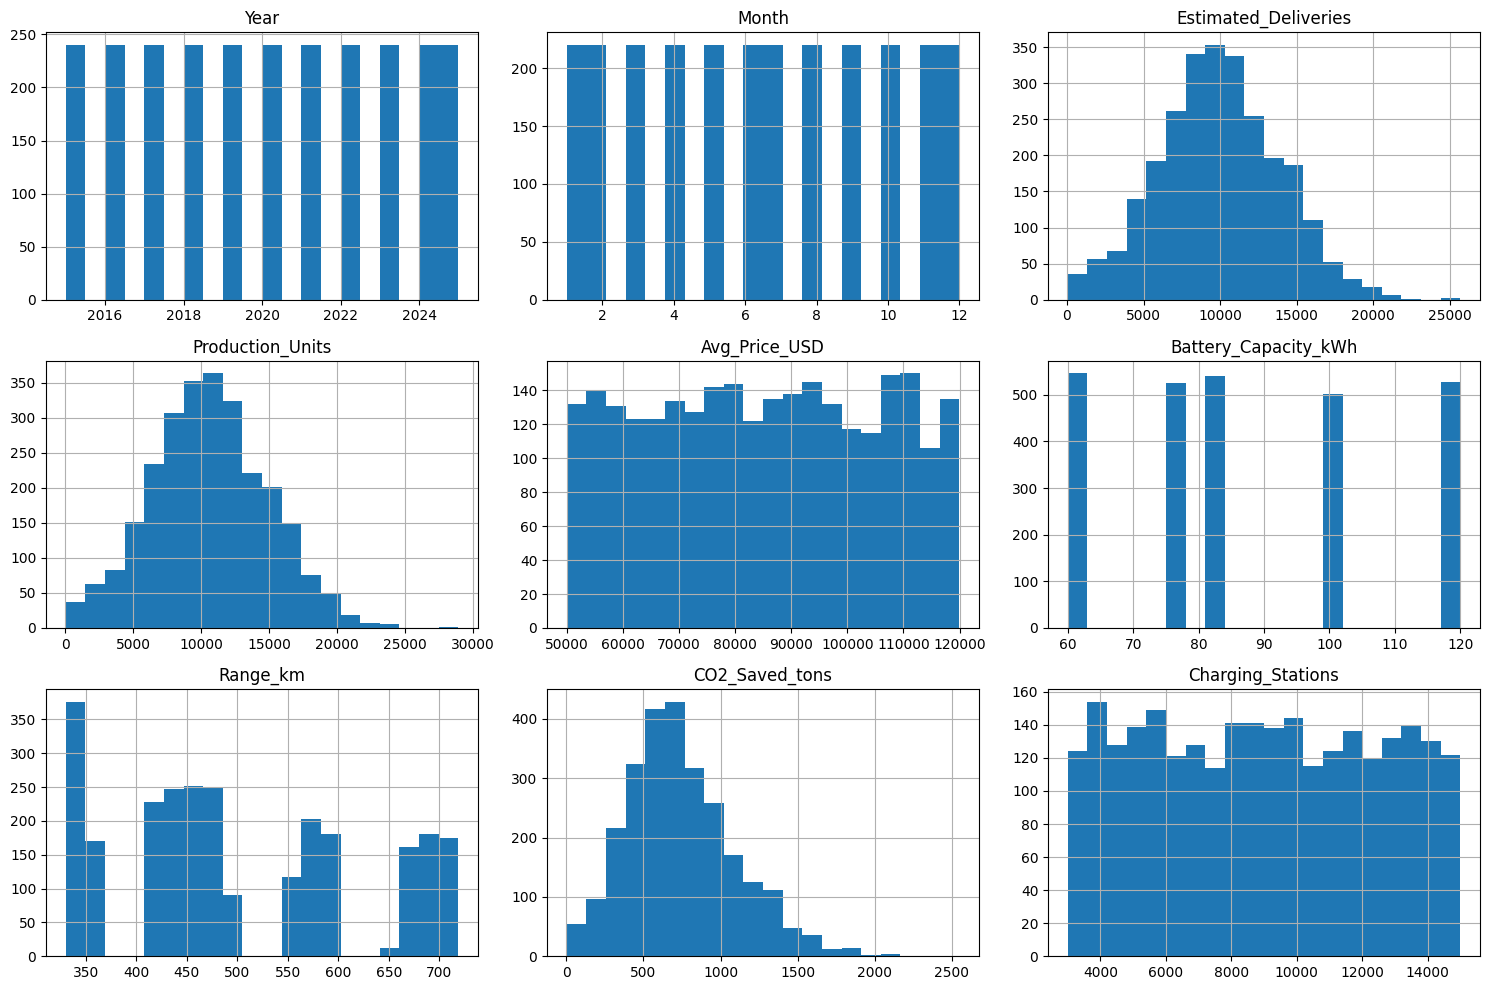

In [11]:
num_cols = df.select_dtypes(include='number').columns

df[num_cols].hist(figsize=(15,10), bins=20)

plt.tight_layout()

plt.show()

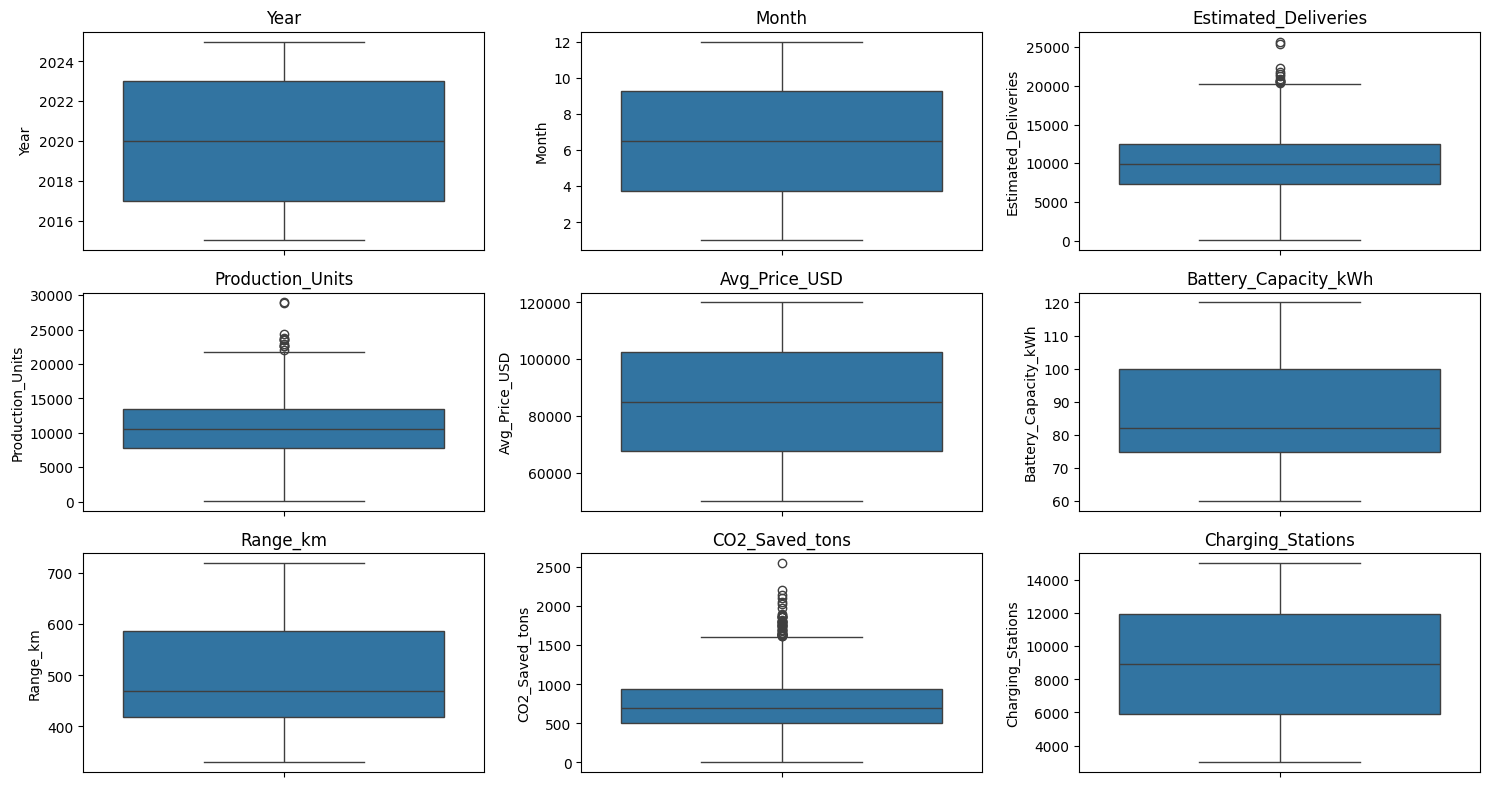

In [12]:
plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

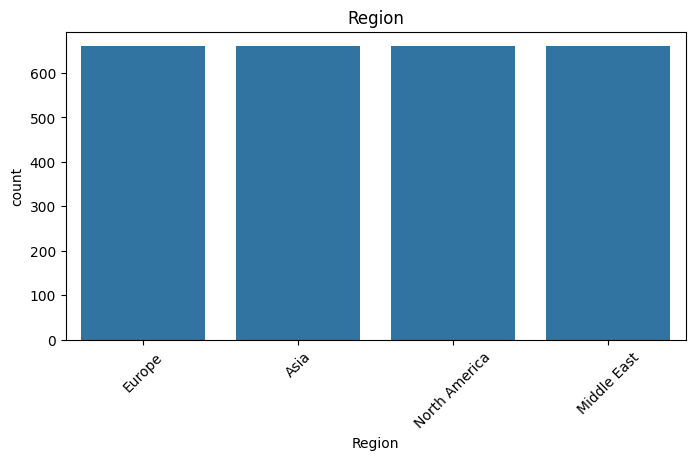

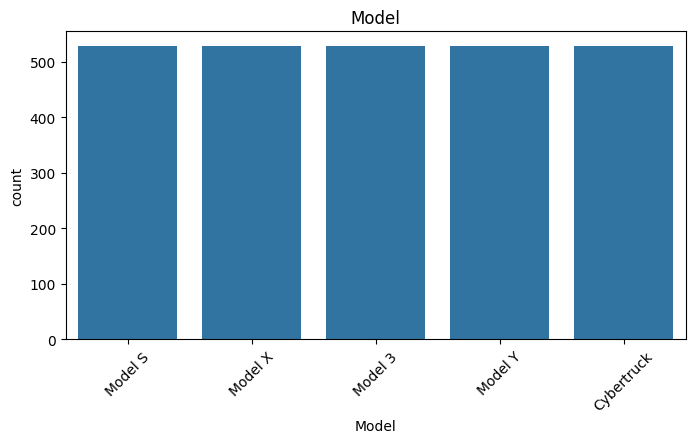

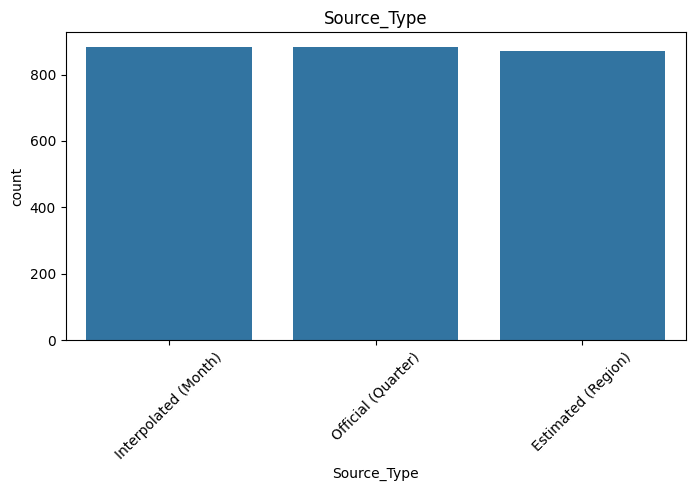

In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

In [14]:
corr = df[num_cols].corr()

corr

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
Year,1.000000e+00,2.216119e-15,-0.002863,-0.002761,-0.004991,-0.030486,-0.029128,-0.019244,-0.003466
Month,2.216119e-15,1.000000e+00,0.030877,0.028971,0.024857,0.001714,0.002143,0.032920,-0.011325
Estimated_Deliveries,-2.863112e-03,3.087690e-02,1.000000,0.994234,-0.027546,-0.007765,-0.006606,0.836814,0.000753
Production_Units,-2.760884e-03,2.897149e-02,0.994234,1.000000,-0.029263,-0.004139,-0.002885,0.833770,0.000600
Avg_Price_USD,-4.990980e-03,2.485676e-02,-0.027546,-0.029263,1.000000,-0.018203,-0.017854,-0.028523,-0.017790
Battery_Capacity_kWh,-3.048584e-02,1.714479e-03,-0.007765,-0.004139,-0.018203,1.000000,0.994313,0.498071,-0.005834
Range_km,-2.912765e-02,2.142889e-03,-0.006606,-0.002885,-0.017854,0.994313,1.000000,0.501698,-0.008291
CO2_Saved_tons,-1.924402e-02,3.291988e-02,0.836814,0.833770,-0.028523,0.498071,0.501698,1.000000,-0.007517
Charging_Stations,-3.465622e-03,-1.132526e-02,0.000753,0.000600,-0.017790,-0.005834,-0.008291,-0.007517,1.000000


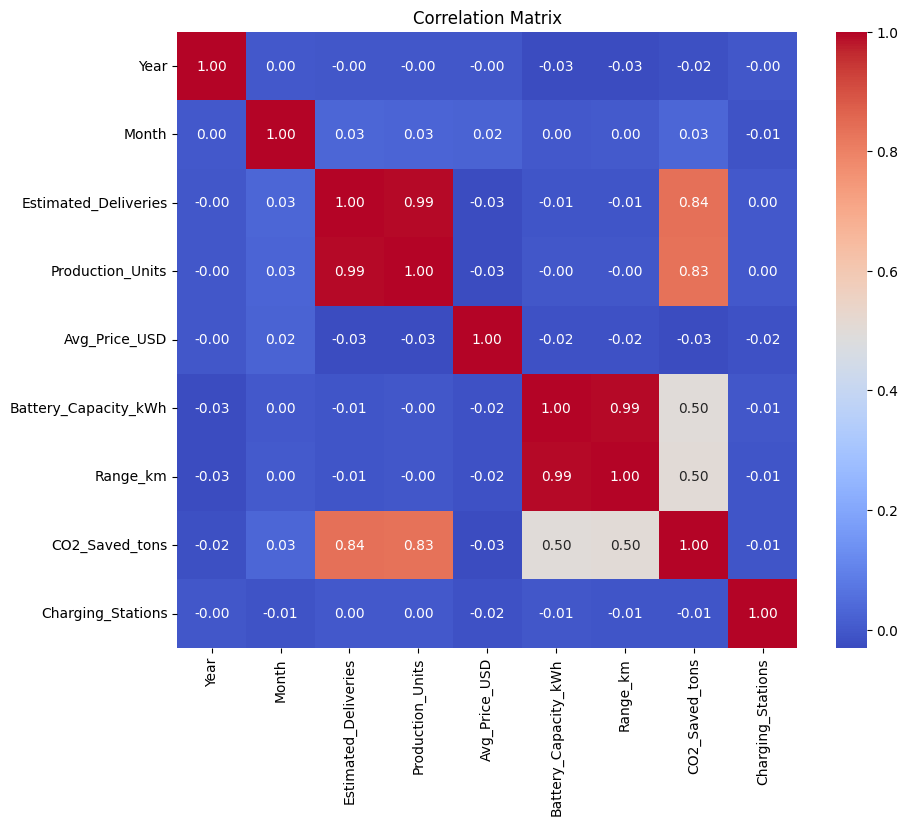

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

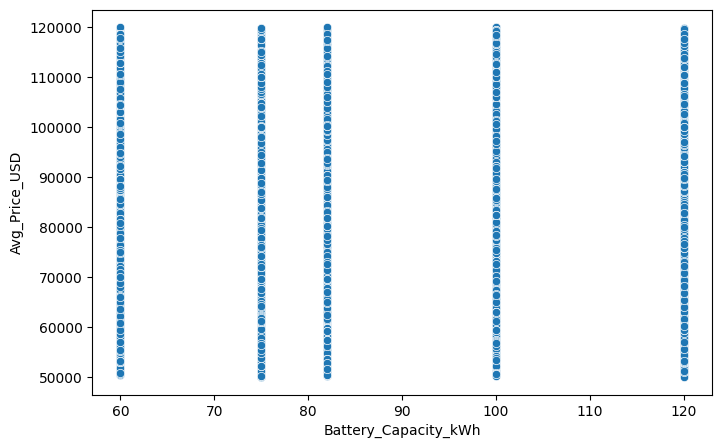

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Battery_Capacity_kWh"],
    y=df["Avg_Price_USD"]
)

plt.show()

# STEP 6 — Encoding Techniques

In [17]:
cat_cols = df.select_dtypes(include="object").columns

print(cat_cols)

Index(['Region', 'Model', 'Source_Type'], dtype='object')


In [18]:
df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [19]:
df_encoded.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,False,True,False,False,False,False,True,False,False


In [20]:
df_encoded.dtypes

,0
Year,int64
Month,int64
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64
Charging_Stations,int64
Region_Europe,bool


In [21]:
print("Original Shape:", df.shape)
print("Encoded Shape :", df_encoded.shape)

Original Shape: (2640, 12)
Encoded Shape : (2640, 18)


# STEP 7 — Feature Scaling

In [22]:
X = df_encoded.drop("Avg_Price_USD", axis=1)

y = df_encoded["Avg_Price_USD"]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [25]:
X_train_scaled = scaler.fit_transform(X_train)

In [26]:
X_test_scaled = scaler.transform(X_test)

In [27]:
print(X_train_scaled[:5])

[[ 0.63248825 -1.30113233  0.15919625  0.14116052 -1.29694104 -1.27475194
  -0.55272372  0.57157752 -0.5860985  -0.57224733  1.73424051 -0.5034009
  -0.50266195 -0.49526056 -0.49674264 -0.72071108 -0.69808591]
 [-0.32439942 -1.59051644 -1.10075369 -1.03881231 -0.57384408 -0.66764545
  -1.1107354   0.58945135 -0.5860985  -0.57224733  1.73424051 -0.5034009
  -0.50266195 -0.49526056  2.01311489  1.38751856 -0.69808591]
 [-1.28128708 -1.59051644  0.13617769  0.04780824 -0.23639884 -0.11043813
   0.05636596  0.79874814 -0.5860985  -0.57224733 -0.57662129 -0.5034009
  -0.50266195 -0.49526056  2.01311489  1.38751856 -0.69808591]
 [-0.00543686 -1.59051644  0.58820149  0.60138726 -0.23639884 -0.32666783
   0.28949775  0.85957682  1.70619785 -0.57224733 -0.57662129 -0.5034009
  -0.50266195  2.01913919 -0.49674264 -0.72071108 -0.69808591]
 [ 1.27041336 -0.72236412  1.36020856  1.5416781  -1.29694104 -1.24148583
   0.17023089 -0.30251046  1.70619785 -0.57224733 -0.57662129 -0.5034009
  -0.50266195

In [28]:
print(X_train_scaled.mean(axis=0))

[-1.31948324e-14  5.04646829e-17 -2.69144976e-17  1.54758361e-16
 -1.12704459e-16 -1.34572488e-17  1.58122673e-16 -6.30808537e-17
  1.05134756e-16 -2.85966537e-17 -2.01858732e-17 -5.59316903e-17
  4.03717464e-17  2.56528805e-17  6.72862439e-17  2.35501854e-17
 -1.00929366e-17]


In [29]:
print(X_train_scaled.std(axis=0))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# STEP 8 — Feature Engineering

In [30]:
df_encoded["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

In [31]:
df_encoded["Delivery_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [32]:
df_encoded["Range_per_kWh"] = (
    df["Range_km"] /
    df["Battery_Capacity_kWh"]
)

In [33]:
df_encoded["CO2_per_Delivery"] = (
    df["CO2_Saved_tons"] /
    df["Estimated_Deliveries"]
)

In [34]:
df_encoded["Charging_per_Delivery"] = (
    df["Charging_Stations"] /
    df["Estimated_Deliveries"]
)

In [35]:
df_encoded["Years_Since_Start"] = (
    df["Year"] -
    df["Year"].min()
)

In [36]:
df_encoded["Price_per_kWh"] = (
    df["Avg_Price_USD"] /
    df["Battery_Capacity_kWh"]
)

In [37]:
df_encoded.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,...,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter),Date,Delivery_Efficiency,Range_per_kWh,CO2_per_Delivery,Charging_per_Delivery,Years_Since_Start,Price_per_kWh
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,True,...,False,True,False,2023-05-01,0.984600,5.866667,0.105600,0.691772,8,773.952250
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,False,...,False,False,True,2015-02-01,0.911864,5.840000,0.065699,2.012115,0,829.408667
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,False,...,False,True,False,2019-01-01,0.915334,5.853659,0.072000,1.672928,4,1437.650244
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,False,...,False,False,True,2021-02-01,0.896594,5.933333,0.106799,1.423799,6,744.124250
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,False,...,True,False,False,2016-12-01,0.914087,5.508333,0.099150,0.704865,1,957.056500


# STEP 9 — Machine Learning Pipelines

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

In [39]:
numerical_columns = [
    "Year",
    "Month",
    "Estimated_Deliveries",
    "Production_Units",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]
categorical_columns = [
    "Region",
    "Model",
    "Source_Type"
]

In [40]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [41]:
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(drop="first"))
    ]
)

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),

        ("cat", categorical_transformer, categorical_columns)
    ]
)

In [43]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("model", LinearRegression())
    ]
)

In [44]:
X = df.drop("Avg_Price_USD", axis=1)

y = df["Avg_Price_USD"]

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Estimated_Deliveries',
                                                   'Production_Units',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', LinearRegression())])

In [47]:
predictions = pipeline.predict(X_test)

In [48]:
print(predictions[:10])

[85645.92332046 84485.21087853 88481.87186493 84578.70941722
 86240.76480308 87110.84113065 82945.31316702 84799.60430296
 85418.60866649 87094.31539205]


# STEP 10 — Linear Regression

In [49]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

In [50]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Estimated_Deliveries',
                                                   'Production_Units',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', LinearRegression())])

In [51]:
y_pred = pipeline.predict(X_test)

In [52]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
2005,77791.05,85645.923320
32,100029.16,84485.210879
962,68450.11,88481.871865
1461,86288.53,84578.709417
478,109940.95,86240.764803
1272,76738.60,87110.841131
211,97193.45,82945.313167
1309,61250.09,84799.604303
1745,103430.64,85418.608666
1498,91557.92,87094.315392


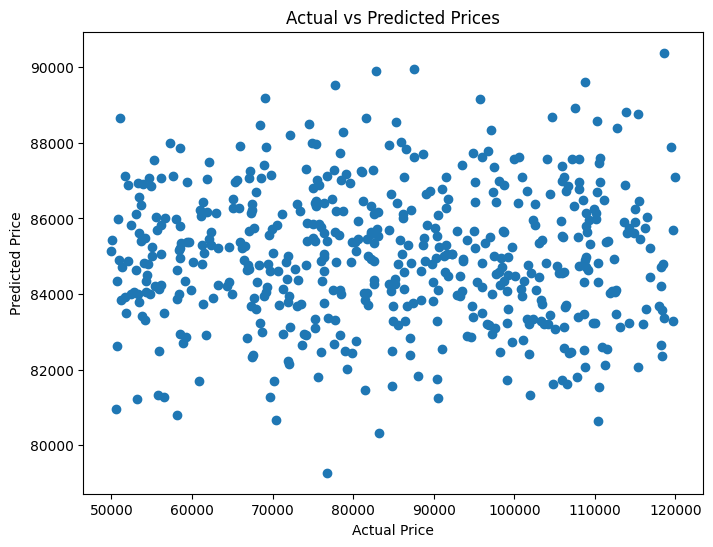

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

In [54]:
residuals = y_test - y_pred

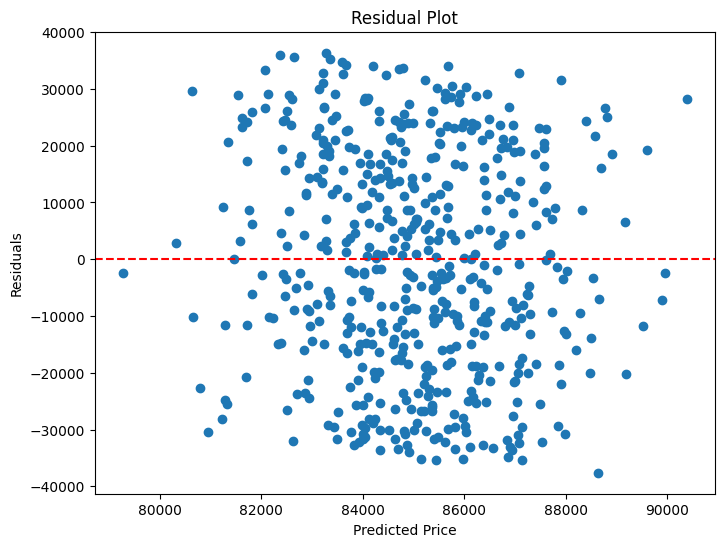

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

# STEP 11 — Model Evaluation

In [56]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [57]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

MAE : 16822.64850744238


In [58]:
mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

MSE : 380741239.9980116


In [59]:
rmse = np.sqrt(mse)

print("RMSE :", rmse)

RMSE : 19512.591831891827


In [60]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : -0.009621802206166485


In [61]:
print("="*40)

print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R2   : {r2:.4f}")

print("="*40)

MAE  : 16822.65
MSE  : 380741240.00
RMSE : 19512.59
R2   : -0.0096


In [62]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

evaluation

,Metric,Value
0,MAE,1.682265e+04
1,MSE,3.807412e+08
2,RMSE,1.951259e+04
3,R2 Score,-9.621802e-03


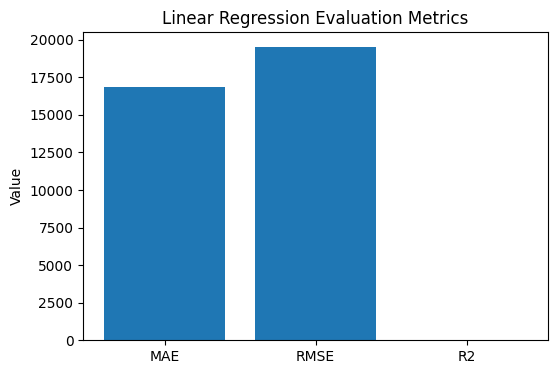

In [63]:
metrics = ["MAE", "RMSE", "R2"]

values = [mae, rmse, r2]

plt.figure(figsize=(6,4))

plt.bar(metrics, values)

plt.title("Linear Regression Evaluation Metrics")

plt.ylabel("Value")

plt.show()

# STEP 12 — Ridge Regression

In [64]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)

In [66]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Estimated_Deliveries',
                                                   'Production_Units',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', Ridge())])

In [67]:
ridge_pred = ridge_pipeline.predict(X_test)

In [68]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_pred)

In [69]:
print("="*40)

print("RIDGE REGRESSION RESULTS")

print("="*40)

print(f"MAE  : {ridge_mae:.2f}")

print(f"MSE  : {ridge_mse:.2f}")

print(f"RMSE : {ridge_rmse:.2f}")

print(f"R²   : {ridge_r2:.4f}")

RIDGE REGRESSION RESULTS
MAE  : 16818.34
MSE  : 380557008.91
RMSE : 19507.87
R²   : -0.0091


In [70]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Linear Regression": [mae, rmse, r2],
    "Ridge Regression": [ridge_mae, ridge_rmse, ridge_r2]
})

comparison

,Metric,Linear Regression,Ridge Regression
0,MAE,16822.648507,16818.339715
1,RMSE,19512.591832,19507.870435
2,R2 Score,-0.009622,-0.009133


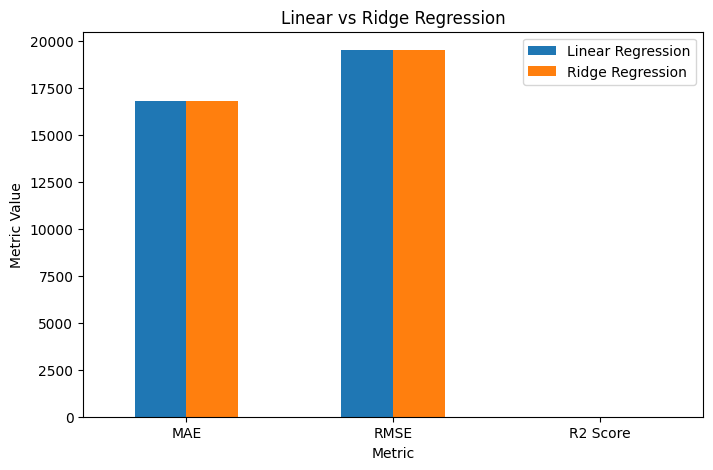

In [71]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Linear vs Ridge Regression")

plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.show()

# STEP 13 — Lasso Regression

In [72]:
from sklearn.linear_model import Lasso
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=1.0))
    ]
)

In [73]:
lasso_pipeline.fit(X_train, y_train)
lasso_pred = lasso_pipeline.predict(X_test)


In [74]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("MAE :", lasso_mae)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)

MAE : 16820.729929188357
RMSE: 19510.054889062947
R²  : -0.00935928594947999


In [75]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Linear": [mae, rmse, r2],
    "Ridge": [ridge_mae, ridge_rmse, ridge_r2],
    "Lasso": [lasso_mae, lasso_rmse, lasso_r2]
})

comparison

,Metric,Linear,Ridge,Lasso
0,MAE,16822.648507,16818.339715,16820.729929
1,RMSE,19512.591832,19507.870435,19510.054889
2,R2,-0.009622,-0.009133,-0.009359


#STEP 14 — Hyperparameter Tuning

In [76]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

In [77]:
grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [78]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Estimated_Deliveries',
                                                                          'Production_Units',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first'))]),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('model', Ridge())]),
             n_jobs=-1, param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [80]:
print("Best Alpha:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)

Best Alpha: {'model__alpha': 100}
Best R² Score: -0.005818857618297768


In [81]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [82]:
print("MAE :", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R²  :", r2_score(y_test, y_pred_best))

MAE : 16774.593984749503
RMSE: 19455.784181411578
R²  : -0.003751669288511117


# STEP 15 — Cross Validation

In [83]:
from sklearn.model_selection import cross_val_score

In [84]:
cv_scores = cross_val_score(
    ridge_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

In [85]:
print("Cross Validation Scores:")
print(cv_scores)
print("Average R² Score:", cv_scores.mean())

Cross Validation Scores:
[-0.01548592 -0.00381711 -0.00586745 -0.01548986  0.00204118]
Average R² Score: -0.007723831790578939


# STEP 16 — Time Series Forecasting

In [86]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

In [87]:
df = df.sort_values("Date")

In [88]:
df.set_index("Date", inplace=True)

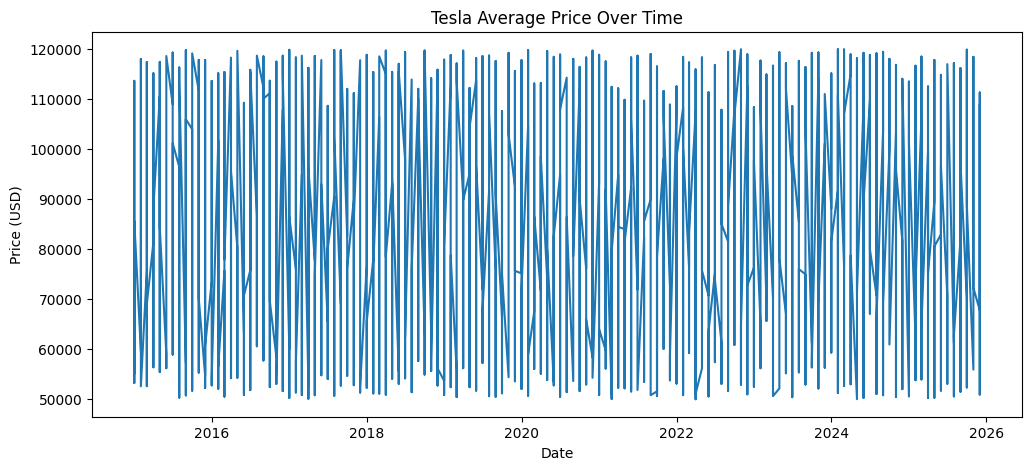

In [89]:
plt.figure(figsize=(12,5))

plt.plot(df["Avg_Price_USD"])

plt.title("Tesla Average Price Over Time")

plt.xlabel("Date")

plt.ylabel("Price (USD)")

plt.show()

In [90]:
df["Price_Lag1"] = df["Avg_Price_USD"].shift(1)
df["Price_Lag2"] = df["Avg_Price_USD"].shift(2)

df["Price_Lag3"] = df["Avg_Price_USD"].shift(3)

In [91]:
df.dropna(inplace=True)

In [92]:
df["Rolling_Mean_3"] = (
    df["Avg_Price_USD"]
    .rolling(window=3)
    .mean()
)

In [93]:
df.dropna(inplace=True)

In [94]:
X = df[[
    "Price_Lag1",
    "Price_Lag2",
    "Price_Lag3",
    "Rolling_Mean_3"
]]

y = df["Avg_Price_USD"]

In [95]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [96]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [97]:
forecast = model.predict(X_test)

In [98]:
print("MAE :", mean_absolute_error(y_test, forecast))
print("RMSE:", np.sqrt(mean_squared_error(y_test, forecast)))
print("R²  :", r2_score(y_test, forecast))

MAE : 7.414021326027513e-11
RMSE: 8.46262802826347e-11
R²  : 1.0


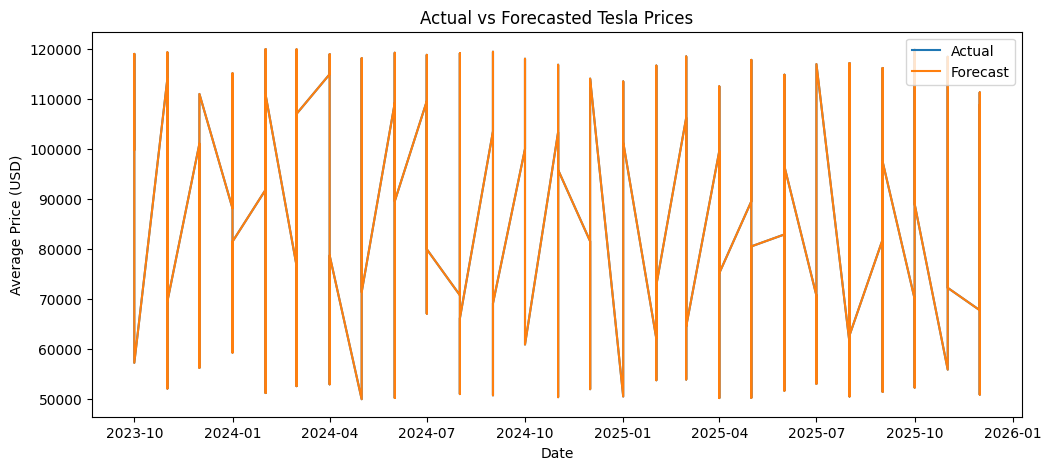

In [99]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test,
         label="Actual")

plt.plot(y_test.index, forecast,
         label="Forecast")

plt.title("Actual vs Forecasted Tesla Prices")

plt.xlabel("Date")

plt.ylabel("Average Price (USD)")

plt.legend()

plt.show()